# Credit Card Fraud Detection

Since this is a credit card fraud detection project, we are dealing with:

    A classification problem (fraud vs. non-fraud)

    A highly imbalanced dataset (fraud cases are much rarer than normal transactions)

    The need for feature engineering and model evaluation

Goal:
    Detect fraudulent credit card transactions with high precision while minimizing false positives.

This dataset is from https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?utm_source=chatgpt.com

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

## Load the dataset and Undrestand It(EDA)

In [3]:
file_path = 'data\creditcard.csv'
df = pd.read_csv(file_path)
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


There are `284807` rows and `31` columns in the dataset. There is no null data. All of features are numerical.

`Time` and `Amount`: Float values representing transaction time (in seconds) and transaction amount.

`V1` to `V28`: Anonymized features transformed using PCA (Principal Component Analysis).

Our target variable is `Class`(`0`=Not Fraud, `1`=Fraud). The dataset is highly imbalancced as we have `284315` value as `0` and only `492` as `1`.



### Find Patterns

#### Exploring Transaction Amounts

In [7]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


C:\Users\user\AppData\Local\Temp\ipykernel_23096\1166819179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Class'], y=df['Amount'], showfliers=False, palette='coolwarm', showmeans=True)


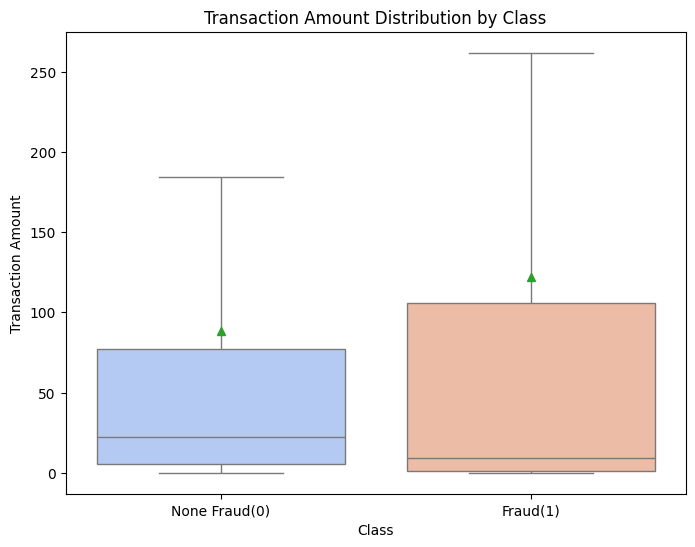

In [8]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Class'], y=df['Amount'], showfliers=False, palette='coolwarm', showmeans=True)
plt.xticks(ticks=[0, 1], labels=['None Fraud(0)', 'Fraud(1)'])
plt.ylabel('Transaction Amount')
plt.title('Transaction Amount Distribution by Class')
plt.show()

In this boxplot:

The median of Fraud box is lower than None Fraud box, meaning that many frauds involve small amounts. However there are some very-high fraud transactions.

Most None Fraud transactions have lower amounts. There are fewer very-high transactions compared to fraud.

None Fraud transactions have more compact IQR, meaning more transactions are in a consistent range.

Fraud transactions are more vary.

Both classes have outliers.


#### Exploring Fraud Over Time

In [9]:
df['Hour'] = (df['Time'] / 3600) % 24

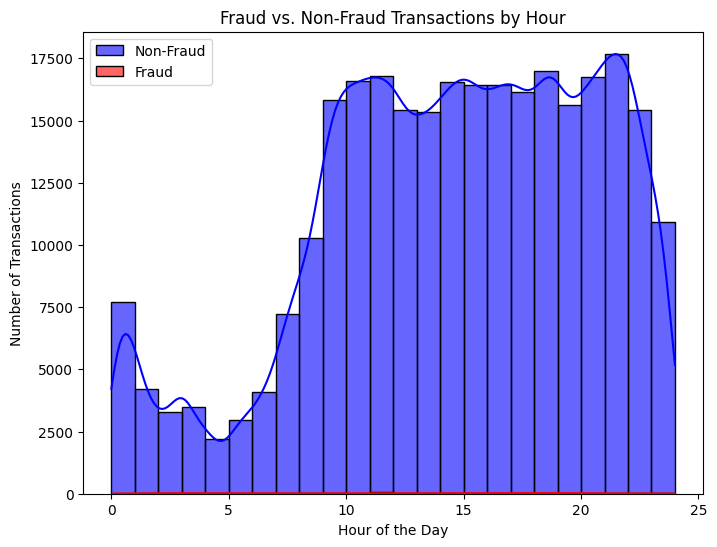

In [10]:
plt.figure(figsize=(8,6))
sns.histplot(df[df['Class']==0]['Hour'], color='Blue', kde=True, bins=24, label='Non-Fraud', alpha=0.6)
sns.histplot(df[df['Class']==1]['Hour'], color='red', kde=True, bins=24, label='Fraud', alpha=0.6)
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Transactions")
plt.title("Fraud vs. Non-Fraud Transactions by Hour")
plt.legend()
plt.show()

Most transactions occur between 9 AM - 9 PM:

    There's a sharp increase in transaction activity around 8-9 AM.

    The highest number of transactions happens throughout the day and starts declining after 9 PM.

2️ Few transactions occur between 12 AM - 6 AM:

    We see a low activity period at night, which is expected (fewer people are shopping or making payments at night).

3️ Fraud Transactions Are Hard to See:

    The red fraud line is barely visible compared to non-fraud transactions (blue).
    
    This is because fraud cases are very rare (0.17% of the data).
    
    We may need to adjust the scale or plot fraud separately to see trends better.

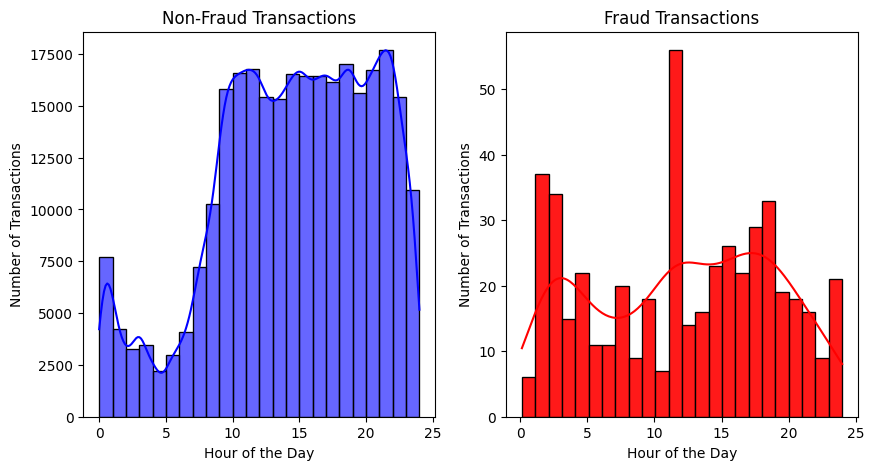

'\nfig, ax1 = plt.subplots(figsize=(10, 5))\n\n# First y-axis (Non-Fraud Transactions)\nsns.histplot(df[df[\'Class\'] == 0][\'Hour\'], bins=24, kde=True, color=\'blue\', label="Non-Fraud", alpha=0.6, ax=ax1)\nax1.set_ylabel("Non-Fraud Transactions")\nax1.set_xlabel("Hour of the Day")\nax1.set_title("Fraud vs. Non-Fraud Transactions by Hour (Final Fix)")\nax1.legend(loc="upper left")\n\n# Create second y-axis for Fraud Transactions\nax2 = ax1.twinx()\nsns.histplot(df[df[\'Class\'] == 1][\'Hour\'], bins=24, kde=True, color=\'red\', label="Fraud", alpha=0.9, linewidth=2, ax=ax2)\nax2.set_ylabel("Fraud Transactions (Linear Scale)")\nax2.legend(loc="upper right")\n\nplt.show()\n'

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.histplot(df[df['Class']==0]['Hour'],  bins=24, kde=True, color='blue', alpha=0.6, ax=axes[0])
sns.histplot(df[df['Class']==1]['Hour'], bins=24, kde=True, color='red', alpha=0.9, ax=axes[1])
axes[0].set_title("Non-Fraud Transactions")
axes[0].set_xlabel("Hour of the Day")
axes[0].set_ylabel("Number of Transactions")
axes[1].set_title("Fraud Transactions")
axes[1].set_ylabel("Number of Transactions")
axes[1].set_xlabel("Hour of the Day")
plt.show()

'''
fig, ax1 = plt.subplots(figsize=(10, 5))

# First y-axis (Non-Fraud Transactions)
sns.histplot(df[df['Class'] == 0]['Hour'], bins=24, kde=True, color='blue', label="Non-Fraud", alpha=0.6, ax=ax1)
ax1.set_ylabel("Non-Fraud Transactions")
ax1.set_xlabel("Hour of the Day")
ax1.set_title("Fraud vs. Non-Fraud Transactions by Hour (Final Fix)")
ax1.legend(loc="upper left")

# Create second y-axis for Fraud Transactions
ax2 = ax1.twinx()
sns.histplot(df[df['Class'] == 1]['Hour'], bins=24, kde=True, color='red', label="Fraud", alpha=0.9, linewidth=2, ax=ax2)
ax2.set_ylabel("Fraud Transactions (Linear Scale)")
ax2.legend(loc="upper right")

plt.show()
'''

1️⃣ Fraud Cases Are More Evenly Distributed Across Hours:

    Unlike non-fraud transactions (which peak between 9 AM - 9 PM), fraud transactions do not follow a strong hourly trend.

This suggests fraud is more spread out throughout the day, meaning fraudsters do not necessarily attack during peak hours.

🛠 Implication for Fraud Detection:

    A time-based fraud detection rule (e.g., “Flag all transactions at night”) would not be effective.

    Time alone is not a strong fraud indicator, but it might still be useful when combined with other features.

2️⃣ Slightly Higher Fraud Activity at Night (0 - 6 AM)

    While fraud cases happen at all hours, there’s a slight increase in fraud activity between midnight and early morning.

    This aligns with real-world fraud behavior:

    Lower monitoring by banks at night.

    Less human oversight on transactions during off-business hours.

🛠 Implication for Fraud Detection:

    Fraud does not happen only at night, but extra monitoring during off-hours may help catch some cases.

    Could be useful when combined with transaction amount (e.g., large transactions at odd hours = higher risk).

3️⃣ Non-Fraud Transactions Peak During Business Hours

    As expected, non-fraud transactions spike between 9 AM - 9 PM, when people are most active in shopping, banking, and making payments.

    After 9 PM, transaction volume gradually decreases.

🛠 Implication for Fraud Detection:

    Normal transactions mostly follow expected human behavior (higher in business hours).

    Fraudulent transactions are more random, meaning fraud detection models cannot rely solely on time-based patterns.


#### Feature Correlation Analysis

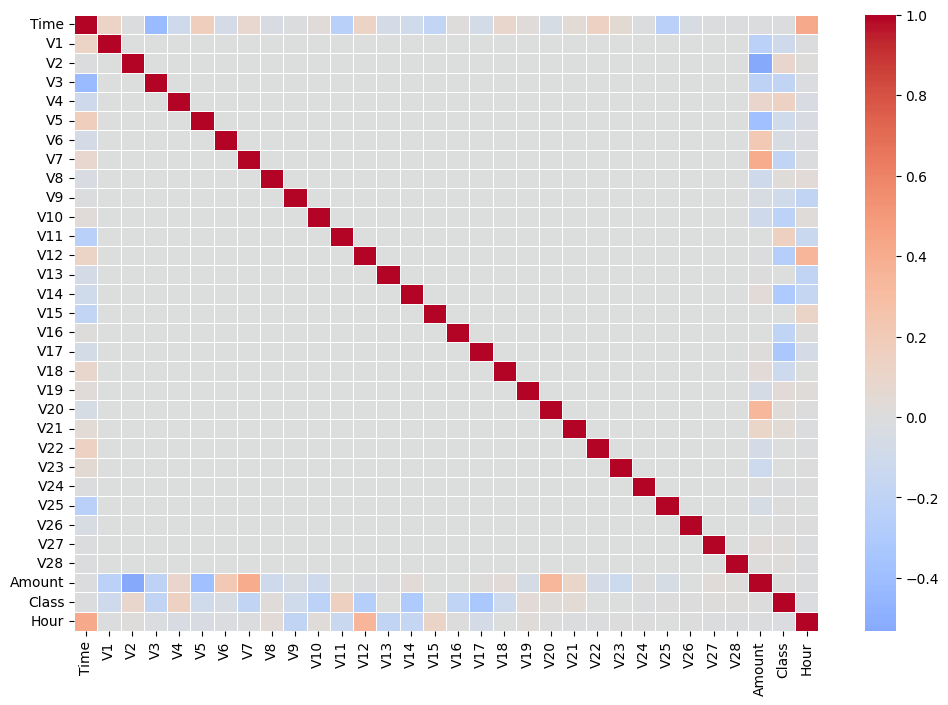

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', fmt='.2f', annot=False, center=0, linewidths=0.5)
plt.show()

In [13]:
correlation_with_fraud = df.corr()["Class"].sort_values(ascending=False)
print(correlation_with_fraud)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
Hour     -0.017082
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_23096\147623571.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Class'], y=df[feature], palette=['blue', 'red'], showmeans=True)
C:\Users\user\AppData\Local\Temp\ipykernel_23096\147623571.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Class'], y=df[feature], palette=['blue', 'red'], showmeans=True)
C:\Users\user\AppData\Local\Temp\ipykernel_23096\147623571.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Class'], y=df[feature], palette=['blue', 'red'], showmeans=True)
C

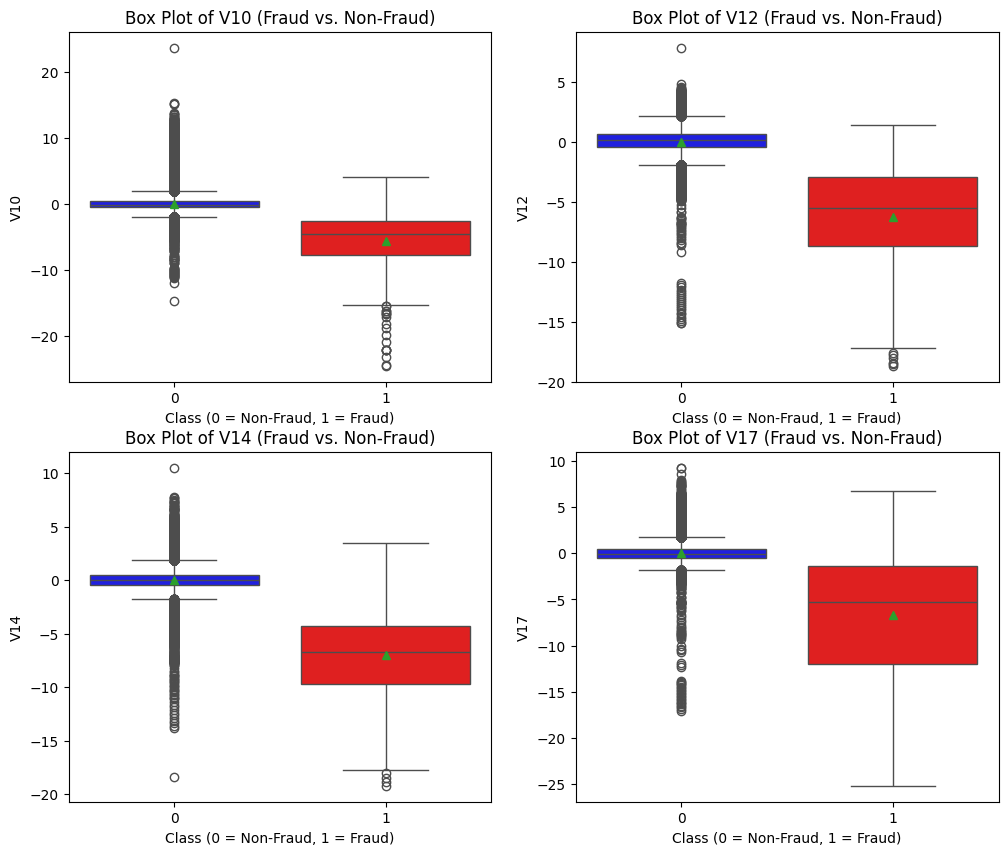

In [14]:
important_features = ['V10', 'V12', 'V14', 'V17']
plt.figure(figsize=(12,10))

for i, feature in enumerate(important_features, 1):
    plt.subplot(2,2, i)
    sns.boxplot(x=df['Class'], y=df[feature], palette=['blue', 'red'], showmeans=True)
    plt.title(f"Box Plot of {feature} (Fraud vs. Non-Fraud)")
    plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
    plt.ylabel(feature)

plt.show()

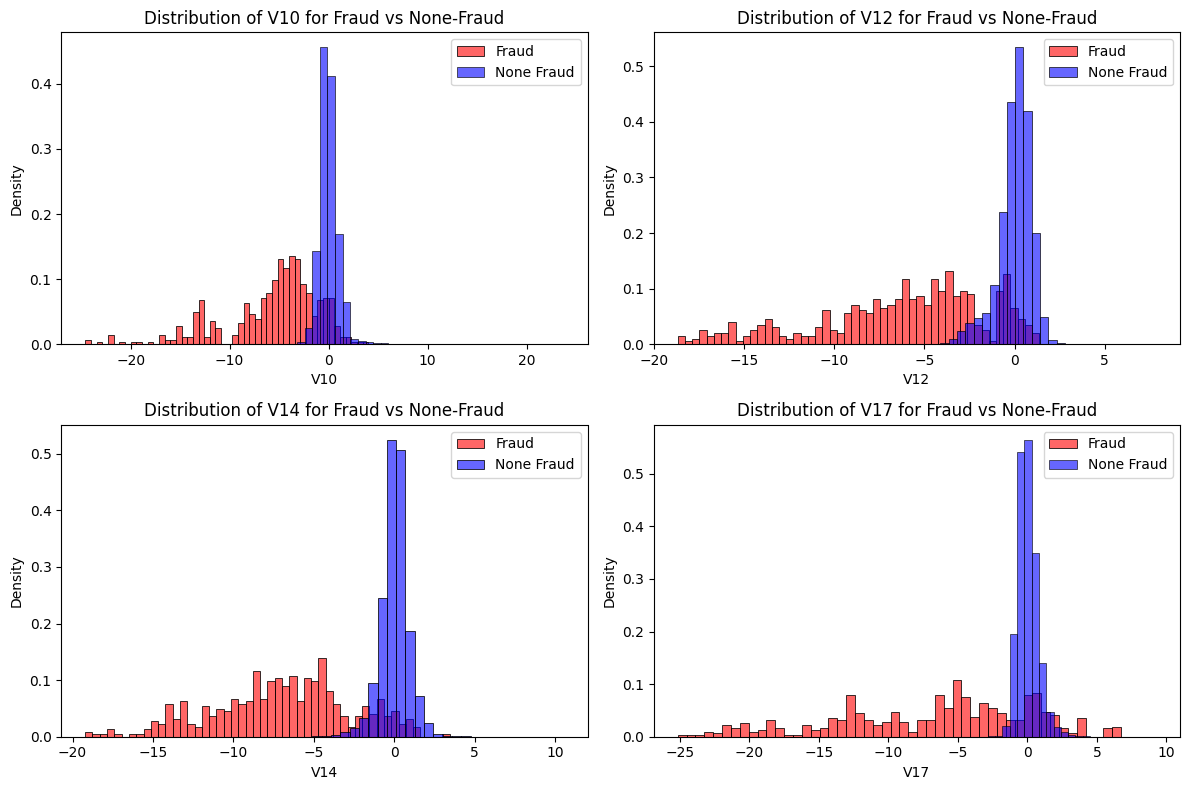

In [20]:
fraud = df[df['Class']==1]
non_fraud = df[df['Class']==0]

plt.figure(figsize=(12,8))

for i, feature in enumerate(important_features, 1):
    plt.subplot(2,2,i)
    sns.histplot(fraud[feature], bins=50, color='red', label='Fraud', alpha=0.6, stat='density')
    sns.histplot(non_fraud[feature], bins=50, color='blue', label='None Fraud', alpha=0.6, stat='density')
    plt.legend()
    plt.title(f'Distribution of {feature} for Fraud vs None-Fraud')

plt.tight_layout()
plt.show()

## Feature Scaling

In [24]:
# Initialize scalers
scaler_amount = StandardScaler()
scaler_time = MinMaxScaler()

# Apply scaling
df['Amount'] = scaler_amount.fit_transform(df[['Amount']])
df['Time'] = scaler_time.fit_transform(df[['Time']])

# Confirm transformation
df[["Amount", "Time"]].describe()

,Amount,Time
count,2.848070e+05,284807.000000
mean,-1.596686e-17,0.548717
std,1.000002e+00,0.274828
min,-3.532294e-01,0.000000
25%,-3.308401e-01,0.313681
50%,-2.652715e-01,0.490138
75%,-4.471707e-02,0.806290
max,1.023622e+02,1.000000


#### Handling the Imbalanced Data

In [40]:
# Separate features (X) and target variable (y)
X = df.drop(columns=['Class'])
y = df['Class']

# Apply SMOTE
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

c:\Users\user\OneDrive\Desktop\Credit_Card_Fraud_Detection\ccf\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## Model Training

In [48]:
# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Check the shape of the new datasets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((454904, 31), (113726, 31), (454904,), (113726,))

In [49]:
len(y)

284807

In [45]:
# Initialize Random Forest model with default settings
rf_model = RandomForestClassifier(random_state=42, n_jobs=1)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Print results
print(f"Model Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

Model Accuracy: 0.9999
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



Since its too perfect, lets try it on the original dataset.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

rf_model_orginal = RandomForestClassifier(random_state=42, n_jobs=1)

rf_model_orginal.fit(X_train, y_train)

y_pred = rf_model_orginal.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(report)

Accuracy: 0.9996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.80      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



Our Recall became lower, so we will try to improve it.

In [53]:
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],  # Number of trees
    'max_depth': [10, 20],  # Tree depth
    'min_samples_split': [2, 5],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2],  # Minimum samples per leaf
    'class_weight': ['balanced']  # Give fraud cases more importance
}

# Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42, n_jobs=1)

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Train the best model
best_rf = grid_search.best_estimator_

# Make predictions
y_pred_tuned = best_rf.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)

# Print results
print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")
print("Classification Report After Tuning:\n", report_tuned)

Best Hyperparameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Model Accuracy: 0.9994
Classification Report After Tuning:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



The model improved recall from 0.80 to 0.82, meaning it detects more actual fraud cases, even though precision dropped slightly.

## Feature Importances

C:\Users\user\AppData\Local\Temp\ipykernel_23096\2635708103.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df['Importance'], y=feature_importance_df['Feature'], palette="viridis")


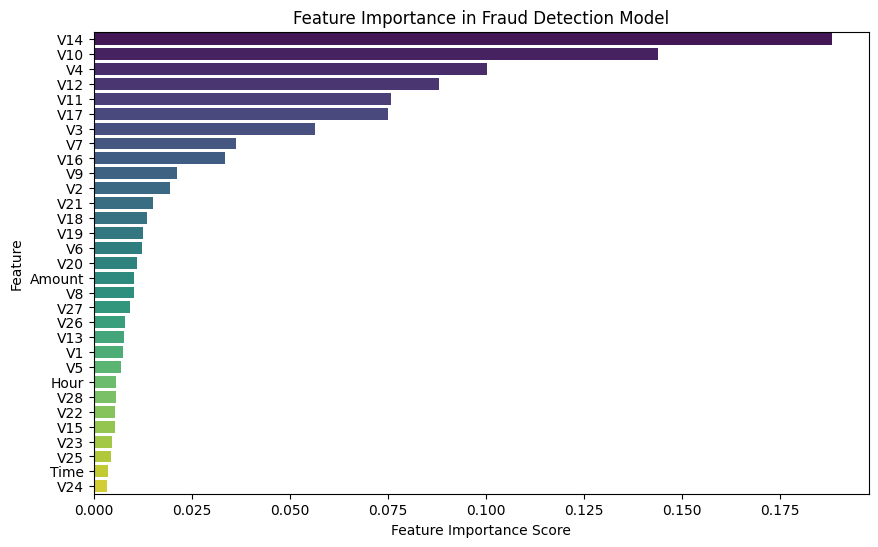

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = best_rf.feature_importances_

# Create a DataFrame to store feature names and importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df['Importance'], y=feature_importance_df['Feature'], palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance in Fraud Detection Model")
plt.show()